# Posttest 1 - Eksplorasi Dataset
**Nama:** Rahmat Riyadi

**NIM:** 2409106074

**Dataset:** Medical Cost Personal Dataset (Insurance Dataset)

**Sumber:** https://www.kaggle.com/datasets/mirichoi0218/insurance

Dataset ini berisi data biaya asuransi kesehatan dari beberapa peserta di Amerika Serikat.
Dataset ini punya campuran kolom angka (numerik) dan kolom kategori (object), sehingga sangat cocok untuk saya guanakan untuk latihan eksplorasi data (EDA).

Kolom yang ada di dataset:
- `age` (angka) : umur peserta
- `sex` (kategori) : jenis kelamin
- `bmi` (angka) : Body Mass Index
- `children` (angka) : jumlah anak/tanggungan
- `smoker` (kategori) : status merokok
- `region` (kategori) : wilayah tempat tinggal
- `charges` (angka) : biaya asuransi yang dikenakan (target label)


In [39]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


## 1. Load Dataset
Dataset diambil langsung dari link mirror GitHub, karena isinya sama persis dengan dataset aslinya di Kaggle. Dengan cara ini notebook bisa langsung dijalankan tanpa perlu setting API key Kaggle dulu.


In [40]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 2A. Informasi Umum Dataset
Bagian ini menampilkan jumlah record (baris), jumlah attribute (kolom), nama-nama attribute, dan jumlah attribute yang bertipe angka.

In [41]:
jumlah_record = df.shape[0]
jumlah_attribute = df.shape[1]
nama_attribute = df.columns.tolist()
attribute_numerik = df.select_dtypes(include=np.number).columns.tolist()

print("Jumlah record:", jumlah_record)
print("Jumlah attribute:", jumlah_attribute)
print("Nama-nama attribute:", nama_attribute)
print("Jumlah attribute bertipe angka:", len(attribute_numerik))
print("Nama attribute bertipe angka:", attribute_numerik)


Jumlah record: 1338
Jumlah attribute: 7
Nama-nama attribute: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
Jumlah attribute bertipe angka: 4
Nama attribute bertipe angka: ['age', 'bmi', 'children', 'charges']


### 2B. Pengecekan Kualitas Data (Missing Values & Duplikat)
Sebelum melakukan analisis lebih jauh, penting untuk memastikan bahwa dataset tidak memiliki nilai yang kosong (*missing values*) dan tidak ada baris data yang ganda (*duplicate records*).

In [42]:
print("Jumlah Missing Values per Attribute:")
print(df.isnull().sum())
print("-" * 30)

jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah Record Duplikat: {jumlah_duplikat}")

Jumlah Missing Values per Attribute:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
------------------------------
Jumlah Record Duplikat: 1


In [43]:
print("Tampilan data yang duplikat:")
display(df[df.duplicated(keep=False)])
df.drop_duplicates(inplace=True)

# Memastikan jumlah record terbaru
print(f"\nJumlah record setelah duplikat dihapus: {df.shape[0]}")

Tampilan data yang duplikat:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631



Jumlah record setelah duplikat dihapus: 1337


## 3. Statistik Deskriptif Attribute Numerik
Menampilkan rata-rata (mean), standar deviasi (std), nilai minimum, nilai maksimum, Q1 (kuartil 1), Q2 (median), dan Q3 (kuartil 3) untuk setiap attribute bertipe angka.

In [44]:
df_numerik = df[attribute_numerik]

statistik = pd.DataFrame({
    "Mean": df_numerik.mean(),
    "Std Dev": df_numerik.std(),
    "Min": df_numerik.min(),
    "Q1 (25%)": df_numerik.quantile(0.25),
    "Q2/Median (50%)": df_numerik.quantile(0.50),
    "Q3 (75%)": df_numerik.quantile(0.75),
    "Max": df_numerik.max(),
})

statistik


,Mean,Std Dev,Min,Q1 (25%),Q2/Median (50%),Q3 (75%),Max
age,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


## 4. 10 Record Pertama
Bagian ini cuma menampilkan kolom yang bertipe angka aja, karena tujuannya buat lihat contoh nilai numerik di dataset. Ditambah juga 10 record terakhir (`tail`), biar kelihatan apakah ada perbedaan pola di awal dan akhir data.

In [45]:
#Dari atas
df_numerik.head(10)


,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
5,31,25.740,0,3756.62160
6,46,33.440,1,8240.58960
7,37,27.740,3,7281.50560
8,37,29.830,2,6406.41070
9,60,25.840,0,28923.13692


In [46]:
# dari bawah
df_numerik.tail(10)

,age,bmi,children,charges
1328,23,24.225,2,22395.74424
1329,52,38.600,2,10325.20600
1330,57,25.740,2,12629.16560
1331,23,33.400,0,10795.93733
1332,52,44.700,3,11411.68500
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500
1337,61,29.070,0,29141.36030


## 5. Jumlah Label pada Attribute Bertipe Object
Setiap attribute yang bertipe object (kategori) dicek jumlah label unik beserta jumlah data di tiap labelnya.

In [47]:
attribute_object = df.select_dtypes(include="object").columns.tolist()
print("Attribute bertipe object:", attribute_object)

for col in attribute_object:
    print(f"\nAttribute '{col}' punya {df[col].nunique()} label unik:")
    print(df[col].value_counts())


Attribute bertipe object: ['sex', 'smoker', 'region']

Attribute 'sex' punya 2 label unik:
sex
male      675
female    662
Name: count, dtype: int64

Attribute 'smoker' punya 2 label unik:
smoker
no     1063
yes     274
Name: count, dtype: int64

Attribute 'region' punya 4 label unik:
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


## 6. Visualisasi Data
### Visualisasi 1: Histogram Distribusi Umur dan Biaya Asuransi
Histogram dipilih karena cocok buat lihat sebaran (distribusi) satu variabel numerik, dalam hal ini umur (`age`) dan biaya asuransi (`charges`). Dari sini bisa kelihatan apakah datanya menyebar merata atau nge-cluster di nilai tertentu.

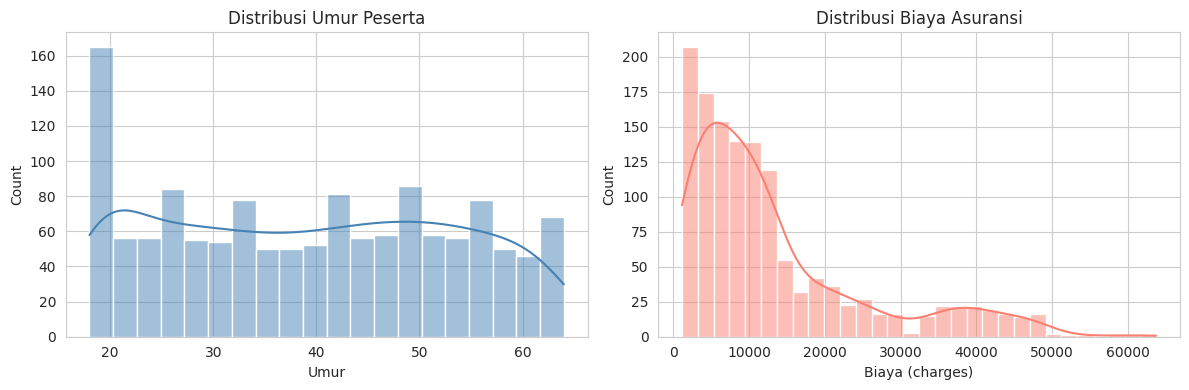

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["age"], bins=20, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribusi Umur Peserta")
axes[0].set_xlabel("Umur")

sns.histplot(df["charges"], bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Distribusi Biaya Asuransi")
axes[1].set_xlabel("Biaya (charges)")

plt.tight_layout()
plt.show()


### Visualisasi 2: Boxplot Biaya Asuransi Berdasarkan Status Merokok
Boxplot dipakai untuk membandingkan sebaran biaya asuransi (`charges`) antara peserta yang merokok dan tidak. Dari grafik ini langsung kelihatan perbedaan median, rentang data, sampai ada tidaknya *outlier* di masing-masing kelompok.


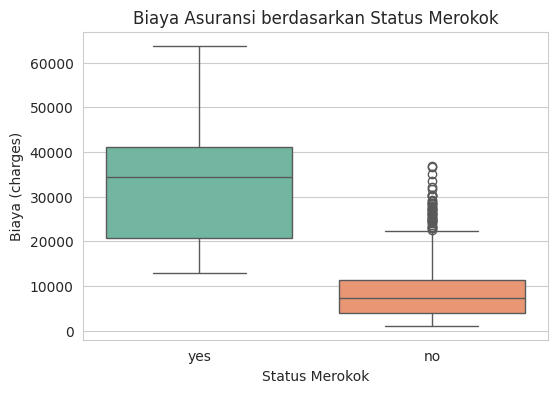

In [49]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="smoker", y="charges", hue="smoker", data=df, palette="Set2", legend=False)
plt.title("Biaya Asuransi berdasarkan Status Merokok")
plt.xlabel("Status Merokok")
plt.ylabel("Biaya (charges)")
plt.show()

## Visualisasi 3: Hubungan Umur dan Biaya Asuransi berdasarkan Status Merokok
Scatter plot dipilih karena cocok untuk lihat hubungan dua variabel numerik sekaligus, yaitu umur dan biaya asuransi. Titik-titiknya dibedakan warnanya berdasarkan status merokok, jadi bisa keliatan apakah pola hubungan umur-biaya ini beda antara perokok dan yang bukan.

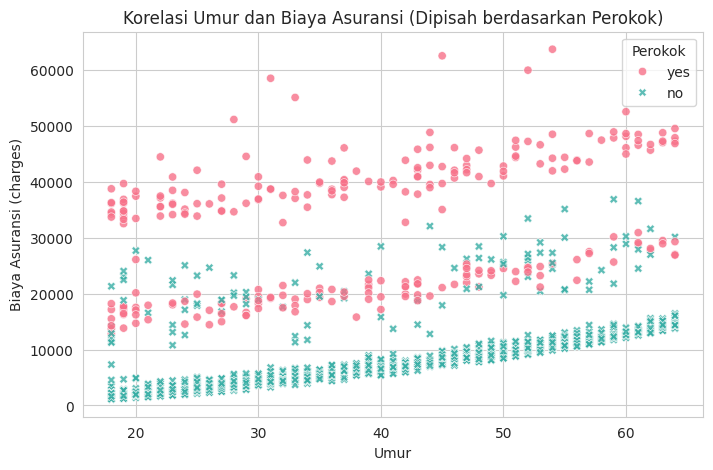

In [50]:
plt.figure(figsize=(8, 5))
# Scatter plot untuk melihat korelasi 3 variabel: umur, biaya, dan perokok
sns.scatterplot(x="age", y="charges", hue="smoker", style="smoker", data=df, palette="husl", alpha=0.8)
plt.title("Korelasi Umur dan Biaya Asuransi (Dipisah berdasarkan Perokok)")
plt.xlabel("Umur")
plt.ylabel("Biaya Asuransi (charges)")
plt.legend(title="Perokok")
plt.show()


## 7. Korelasi Antar Attribute Numerik (Heatmap)
Heatmap dipakai untuk melihat seberapa kuat hubungan (korelasi) antar attribute bertipe angka. Nilai mendekati 1 atau -1 menunjukkan hubungan yang kuat, sedangkan nilai mendekati 0 menunjukkan hubungan yang lemah.

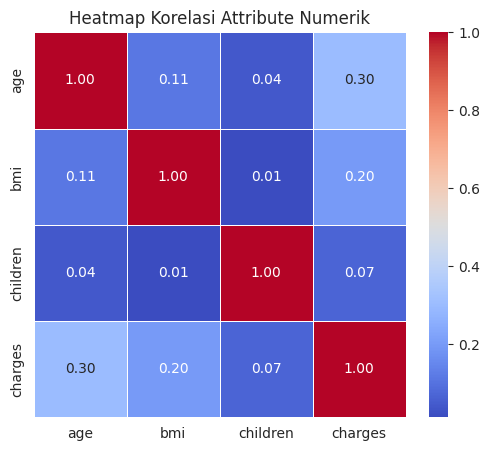

In [51]:
plt.figure(figsize=(6, 5))
korelasi = df_numerik.corr()
sns.heatmap(korelasi, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Attribute Numerik")
plt.show()


## 8. Kesimpulan Eksplorasi

Beberapa hal yang bisa disimpulkan dari eksplorasi dataset ini:

* **Kualitas Data:** Secara keseluruhan data sudah bersih (tidak ada *missing values*), namun ditemukan **1 record duplikat** yang telah dihapus untuk menghindari bias analisis. Total data bersih yang digunakan adalah 1337 record.
* **Distribusi Data:** Rata-rata biaya asuransi (`charges`) cukup tinggi dan sebarannya tidak merata (terdapat *outliers* / nilai yang jauh lebih besar dari rata-rata).
* **Pengaruh Rokok (Bivariat):** Dari *boxplot*, terlihat sangat jelas bahwa peserta yang merokok cenderung membayar biaya asuransi jauh lebih tinggi dibandingkan yang tidak merokok.
* **Korelasi Variabel Numerik:** Dari *heatmap*, `age` dan `charges` memiliki korelasi positif (semakin tua, biaya cenderung semakin naik). `bmi` juga memiliki korelasi positif meski tidak sekuat `age`.
* **Interaksi Multivariat (Umur, Biaya, & Rokok):** Dari *scatter plot*, dapat disimpulkan bahwa kombinasi antara bertambahnya umur dan kebiasaan merokok menghasilkan lonjakan biaya asuransi yang paling ekstrim. Perokok di usia muda bahkan bisa membayar lebih mahal daripada non-perokok di usia tua.

# Posttest 2 - Prapemrosesan Data

Setelah tahap eksplorasi selesai, sekarang datanya disiapkan biar bisa dipakai untuk pelatihan model. Prinsipnya *Garbage In Garbage Out*, jadi kalau data yang masuk kualitasnya jelek, hasil prediksi modelnya juga bakal jelek.

## 1. Data Cleaning

### 1A. Missing Value dan Duplikat
Bagian ini sebenarnya sudah dikerjakan waktu eksplorasi di Posttest 1. Hasil pengecekan `isnull()` waktu itu 0 di semua attribute, jadi tidak ada penanganan nilai hilang yang perlu dilakukan. Sedangkan untuk duplikat, ditemukan **1 record** yang isinya sama persis di ketujuh kolom, termasuk `bmi` dan `charges` yang nilainya desimal. Dua peserta berbeda yang kebetulan cocok di semua kolom itu hampir mustahil, jadi kemungkinan besar datanya memang terinput dua kali dan sudah dihapus pakai `drop_duplicates()` sehingga tersisa 1337 record.

Di sini cuma dilakukan pengecekan ulang aja, buat memastikan data yang dipakai di tahap prapemrosesan ini memang sudah bersih.

In [52]:
print("Jumlah record:", df.shape[0])
print(df.isnull().sum())
print("Duplikat:", df.duplicated().sum())

Jumlah record: 1337
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
Duplikat: 0


### 1B. Handling Outlier

Outlier itu adalah ANOMALIII yakni nilai yang jauh melenceng dari kebanyakan data. Keberadaannya perlu diperiksa karena kalau dibiarkan tanpa sadar, model bisa tertarik ke nilai-nilai ekstrim itu dan jadi kurang stabil.

Metode yang dipakai di sini adalah **IQR (Interquartile Range)**, sama seperti yang dicontohkan di modul. Caranya dengan mengambil nilai kuartil 1 (Q1) dan kuartil 3 (Q3), lalu dihitung selisihnya. Data yang posisinya di bawah `Q1 - 1.5 * IQR` atau di atas `Q3 + 1.5 * IQR` dihitung sebagai outlier.

Tapi sebelum mengambil keputusan mau diapakan, outliernya dideteksi dulu di setiap attribute numerik supaya kelihatan attribute mana saja yang bermasalah dan seberapa banyak jumlahnya.


In [53]:
num_cols = ["age", "bmi", "children", "charges"]

for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    low, up = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n = ((df[col] < low) | (df[col] > up)).sum()
    print(f"{col}: {n} outlier (batas {low:.2f} sampai {up:.2f})")

age: 0 outlier (batas -9.00 sampai 87.00)
bmi: 9 outlier (batas 13.67 sampai 47.32)
children: 0 outlier (batas -3.00 sampai 5.00)
charges: 139 outlier (batas -13120.72 sampai 34524.78)


Selain lewat angka, sebaran outliernya juga divisualisasikan pakai boxplot biar kelihatan langsung di attribute mana titik-titik outliernya menumpuk.

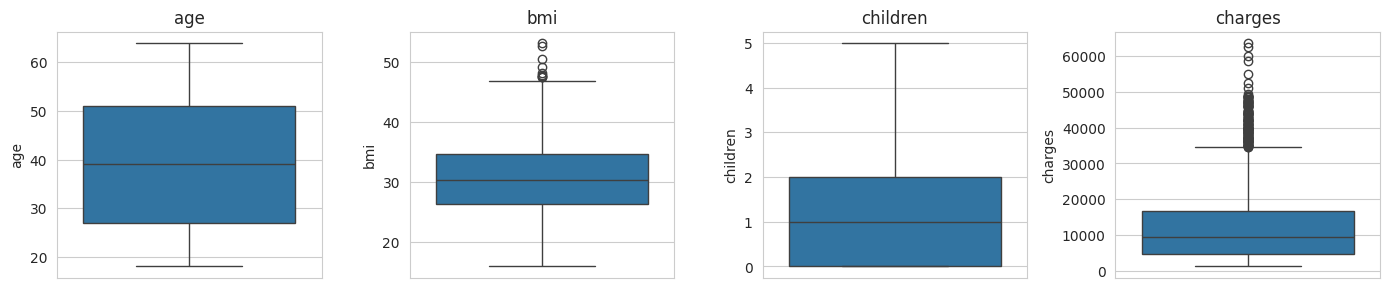

In [54]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Dari hasil deteksi, outlier muncul di `bmi` dan `charges`, tapi keduanya diperlakukan berbeda.

`charges` **dibiarkan apa adanya**. Attribute ini adalah target label, dan dari EDA kemarin sudah kelihatan kalau nilai-nilai tinggi itu memang datang dari peserta PEROKOK. Jadi nilai ekstrim di sini bukan anomali, melainkan pola asli yang justru mau dipelajari modelnya nanti. Kalau dibuang, yang hilang malah informasi pentingnya.

`bmi` ditangani pakai **capping (winsorizing)**, bukan dihapus. Nilainya masih masuk akal sebagai BMI manusia, jadi sayang kalau recordnya dibuang begitu saja. Capping ini cuma membatasi nilainya supaya tidak melewati batas atas IQR, sehingga jumlah datanya tetap utuh tapi pengaruh nilai ekstrimnya berkurang.

In [55]:
df_prep = df.copy()

In [56]:
Q3 = df_prep["bmi"].quantile(0.75)
IQR = Q3 - df_prep["bmi"].quantile(0.25)
batas_atas = Q3 + 1.5 * IQR

df_prep["bmi"] = df_prep["bmi"].clip(upper=batas_atas)
print("Batas atas bmi:", round(batas_atas, 2))
print("Sisa outlier:", (df_prep["bmi"] > batas_atas).sum())

Batas atas bmi: 47.32
Sisa outlier: 0


## 2. Feature Engineering

Di sini dibuat dua attribute baru dari attribute yang sudah ada. Catatan pentingnya, tidak ada satu pun fitur baru yang menyentuh `charges`, karena `charges` itu target label. Kalau fitur barunya diturunkan dari target, modelnya cuma akan "mengintip jawaban" dan hasilnya jadi tidak valid.

1. **`kategori_bmi`** : nilai `bmi` yang berupa angka mentah dikelompokkan jadi kategori medis standar WHO (Underweight, Normal, Overweight, Obese). Fitur ini membantu model menangkap pola per kelompok, bukan cuma angka yang naik turun.
2. **`skor_risiko`** : gabungan dari status merokok dan kondisi obesitas (BMI >= 30), nilainya 0 sampai 2. Dari EDA kemarin kelihatan dua faktor ini yang paling berpengaruh, jadi digabung biar modelnya bisa menangkap peserta yang kena DOUBLE RISIKO.

In [57]:
def kelompok_bmi(nilai):
    if nilai < 18.5:
        return "Underweight"
    elif nilai < 25:
        return "Normal"
    elif nilai < 30:
        return "Overweight"
    return "Obese"

df_prep["kategori_bmi"] = df_prep["bmi"].apply(kelompok_bmi)

In [58]:
df_prep["skor_risiko"] = (df_prep["smoker"] == "yes").astype(int) + (df_prep["bmi"] >= 30).astype(int)
df_prep[["bmi", "kategori_bmi", "smoker", "skor_risiko"]].sample(10)

,bmi,kategori_bmi,smoker,skor_risiko
1003,29.600,Overweight,no,0
853,23.750,Normal,no,0
1292,23.210,Normal,no,0
617,25.600,Overweight,yes,1
756,22.800,Normal,no,0
679,23.180,Normal,no,0
858,32.230,Obese,no,1
1148,21.500,Normal,no,0
1001,32.700,Obese,yes,2
818,26.125,Overweight,yes,1


## 3. Encoding Attribute Kategorikal

Model pembelajaran mesin tidak bisa membaca teks, jadi semua attribute kategorikal harus diubah jadi angka dulu. Tapi caranya tidak sama semua, tergantung attribute itu punya urutan alami atau tidak.

1. **`sex` dan `smoker`** : isinya cuma dua nilai (male/female dan yes/no), jadi cukup dipetakan langsung ke 0 dan 1. 
2. **`region`** : pakai **One-Hot Encoding**, karena wilayah itu TIDAK ADA URUTANNYA. Southeast bukan berarti lebih tinggi dari northwest. Kalau dipaksa dikasih angka 0-1-2-3, model bakal salah paham dan mengira ada tingkatan di antara wilayahnya.
3. **`kategori_bmi`** : pakai **Ordinal Encoding**, karena justru kebalikannya. Underweight sampai Obese itu jelas berurutan dari paling kurus ke paling gemuk. Kalau dipaksa One-Hot, informasi urutan tadi malah hilang.

In [59]:
df_prep["sex"] = df_prep["sex"].map({"female": 0, "male": 1})
df_prep["smoker"] = df_prep["smoker"].map({"no": 0, "yes": 1})

In [60]:
urutan_bmi = {"Underweight": 0, "Normal": 1, "Overweight": 2, "Obese": 3}
df_prep["kategori_bmi"] = df_prep["bmi"].apply(kelompok_bmi).map(urutan_bmi)

In [61]:
df_prep = pd.get_dummies(df_prep, columns=["region"], dtype=int)
df_prep.sample(5)

,age,sex,bmi,children,smoker,charges,kategori_bmi,skor_risiko,region_northeast,region_northwest,region_southeast,region_southwest
666,49,1,28.70,1,0,8703.45600,2,0,0,0,0,1
209,40,1,41.23,1,0,6610.10970,3,1,1,0,0,0
1272,43,1,25.52,5,0,14478.33015,2,0,0,0,1,0
1203,51,1,32.30,1,0,9964.06000,3,1,1,0,0,0
64,20,0,22.42,0,1,14711.74380,1,1,0,1,0,0


## 4. Standarisasi Attribute Numerik

Attribute numerik di dataset ini rentang nilainya beda jauh. `age` cuma puluhan, sedangkan `charges` bisa puluhan ribu. Kalau dibiarkan, attribute dengan angka besar bakal MENDOMINASI dan bikin model salah menilai mana yang benar-benar penting.

Ada dua pilihan metodenya:
- **Normalisasi (Min-Max)** : nilainya dipaksa masuk rentang 0 sampai 1. Cocok kalau sebaran datanya rapi dan batas atas bawahnya jelas.
- **Standarisasi (Z-score)** : nilainya diubah supaya rata-ratanya 0 dan standar deviasinya 1.

Yang dipakai di sini adalah **standarisasi**, karena dari EDA kemarin sebaran datanya tidak merata dan masih ada nilai-nilai ekstrim yang sengaja tidak dibuang. Min-Max bakal terlalu terpengaruh sama nilai paling ujung, sedangkan standarisasi lebih tahan menghadapi kondisi kayak gini.

Yang diskalakan cuma `age`, `bmi`, dan `children`. `charges` sengaja TIDAK ikut diskalakan karena dia target label, jadi nilainya dibiarkan apa adanya supaya hasil prediksi modelnya nanti masih gampang dibaca dalam satuan biaya asli. `skor_risiko` dan `kategori_bmi` juga dilewati karena rentangnya sudah kecil (0 sampai 3).

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
kolom_skala = ["age", "bmi", "children"]
df_prep[kolom_skala] = scaler.fit_transform(df_prep[kolom_skala])

In [63]:
df_prep.sample(10)

,age,sex,bmi,children,smoker,charges,kategori_bmi,skor_risiko,region_northeast,region_northwest,region_southeast,region_southwest
940,-1.511647,1,-1.228293,-0.909234,0,1121.8739,1,0,0,0,1,0
95,-0.799350,0,1.150620,-0.079442,0,3766.8838,3,1,0,0,1,0
873,0.269096,1,-0.090839,-0.079442,0,6849.0260,3,1,0,0,0,1
850,-0.158282,0,0.021421,-0.909234,1,37270.1512,3,2,1,0,0,0
203,-0.870580,0,0.896385,-0.909234,1,37133.8982,3,2,0,0,1,0
66,1.551231,0,1.394950,0.750351,0,14235.0720,3,1,0,0,0,1
718,0.838934,0,0.993787,0.750351,0,10848.1343,3,1,0,1,0,0
1288,-1.369188,1,1.444476,0.750351,1,38344.5660,3,2,0,0,0,1
815,-1.369188,0,0.133680,-0.909234,0,1877.9294,3,1,0,0,1,0
84,-0.158282,0,0.685073,0.750351,1,39836.5190,3,2,0,0,0,1


In [64]:
df_prep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   float64
 1   sex               1337 non-null   int64  
 2   bmi               1337 non-null   float64
 3   children          1337 non-null   float64
 4   smoker            1337 non-null   int64  
 5   charges           1337 non-null   float64
 6   kategori_bmi      1337 non-null   int64  
 7   skor_risiko       1337 non-null   int64  
 8   region_northeast  1337 non-null   int64  
 9   region_northwest  1337 non-null   int64  
 10  region_southeast  1337 non-null   int64  
 11  region_southwest  1337 non-null   int64  
dtypes: float64(4), int64(8)
memory usage: 135.8 KB


## Kesimpulan Prapemrosesan

Dataset sekarang sudah SIAP TEMPUR untuk masuk ke tahap pelatihan model. Dari 1337 record yang bersih, semua attribute sudah berubah jadi bentuk numerik dan tidak ada satu pun nilai yang kosong.

Ringkasan yang sudah dikerjakan:
- **Data Cleaning** : missing value nihil, duplikat sudah dibereskan sejak Posttest 1, dan outlier `bmi` ditangani pakai capping sementara outlier `charges` sengaja dibiarkan karena itu pola asli dari peserta perokok.
- **Feature Engineering** : lahir dua attribute baru, `kategori_bmi` dan `skor_risiko`, dan keduanya murni diturunkan dari attribute selain target label.
- **Encoding** : `sex` dan `smoker` dipetakan ke 0/1, `region` pakai One-Hot karena tidak punya urutan, `kategori_bmi` pakai Ordinal karena justru punya urutan.
- **Standarisasi** : `age`, `bmi`, dan `children` diskalakan pakai Z-score biar rentangnya seimbang, sedangkan `charges` dibiarkan apa adanya supaya hasil prediksi nanti masih gampang dibaca.

Jumlah attribute bertambah dari 7 menjadi 12, dan semuanya sudah bertipe angka.

# Posttest 3 - Machine Learning

Data yang sudah dibersihkan di Posttest 2 akan dipakai buat melatih model di Posttest kali ini. Pendekatan yang saya pilih adalah **Supervised Learning**, karena dataset ini sudah punya label yaitu `charges`, jadi model bisa belajar langsung dari "kunci jawabannya".

Jenis tugasnya **Regresi**, bukan klasifikasi. Soalnya `charges` itu isinya angka kontinu (biaya asuransi dalam dolar), bukan kategori kayak yes/no. Jadi yang mau ditebak model di sini adalah BERAPA biayanya, bukan masuk kelompok mana.

## 1. Menentukan Variabel X dan Y

Variabel Y atau targetnya adalah `charges`, karena itu yang mau diprediksi. Sedangkan variabel X-nya diambil dari semua attribute sisanya hasil prapemrosesan kemarin, yaitu `age`, `sex`, `bmi`, `children`, `smoker`, `kategori_bmi`, `skor_risiko`, dan 4 kolom `region` hasil One-Hot Encoding. Totalnya ada 11 variabel X, jadi syarat minimal 2 variabel X sudah aman terpenuhi.

In [65]:
X = df_prep.drop(columns=["charges"])
y = df_prep["charges"]

print("Jumlah variabel X:", X.shape[1])
print("Nama variabel X:", X.columns.tolist())

Jumlah variabel X: 11
Nama variabel X: ['age', 'sex', 'bmi', 'children', 'smoker', 'kategori_bmi', 'skor_risiko', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


## 2. Data Splitting

Sebelum dilatih, datanya dibagi dulu jadi dua bagian. **Train set** sebanyak 80% dipakai model buat belajar pola hubungan antara X dan Y. Sisanya 20% jadi **test set**, yaitu data yang BELUM PERNAH DILIHAT model sama sekali. Test set ini penting banget buat ngecek apakah model beneran paham polanya atau cuma menghafal data latihannya aja.

`random_state=42` sengaja dipasang biar pembagian datanya selalu sama setiap kali notebook dijalankan ulang, jadi hasilnya konsisten dan bisa dicek ulang.

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ukuran train:", X_train.shape)
print("Ukuran test :", X_test.shape)

Ukuran train: (1069, 11)
Ukuran test : (268, 11)


## 3. Model 1: Linear Regression

Model pertama yang dipakai adalah **Linear Regression**, sesuai yang dibahas di modul. Karena variabel X-nya lebih dari satu, jenisnya termasuk **Multiple Linear Regression** (regresi linear berganda). Cara kerjanya simpel, model nyari garis (atau lebih tepatnya bidang) lurus yang paling pas buat menggambarkan hubungan antara semua variabel X dengan `charges`.

Model ini sengaja dipakai duluan sebagai **baseline**, alias patokan dasar. Nanti hasilnya dibandingkan sama model lain buat lihat apakah model yang lebih kompleks beneran lebih jago atau nggak.

In [67]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

### Evaluasi Model

Metrik evaluasi yang dipakai ada 3, semuanya khusus buat regresi:
- **MAE (Mean Absolute Error)** : rata-rata selisih antara tebakan model dan nilai aslinya. Satuannya dolar, jadi gampang dibayangkan "rata-rata model meleset berapa dolar".
- **RMSE (Root Mean Squared Error)** : mirip MAE tapi error yang besar dihukum lebih berat karena dikuadratkan dulu. Kalau RMSE jauh lebih besar dari MAE, artinya ada beberapa tebakan yang melesetnya PARAH.
- **R² (R-squared)** : seberapa besar variasi `charges` yang bisa dijelaskan model, rentangnya 0 sampai 1. Makin dekat ke 1 makin bagus.

Biar nggak nulis ulang kode yang sama untuk setiap model, evaluasinya dibungkus jadi satu fungsi. R² juga dihitung di data train, buat ngecek ada overfitting atau nggak. Kalau R² train jauh lebih tinggi dari R² test, berarti modelnya kebanyakan menghafal.

In [68]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluasi(nama, model):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2_train = r2_score(y_train, model.predict(X_train))
    r2_test = r2_score(y_test, pred)
    print(f"{nama}")
    print(f"MAE      : {mae:.2f}")
    print(f"RMSE     : {rmse:.2f}")
    print(f"R² train : {r2_train:.4f}")
    print(f"R² test  : {r2_test:.4f}")
    return {"Model": nama, "MAE": mae, "RMSE": rmse, "R2 Train": r2_train, "R2 Test": r2_test}

In [69]:
hasil_lr = evaluasi("Linear Regression", lr)

Linear Regression
MAE      : 4310.40
RMSE     : 5988.06
R² train : 0.7371
R² test  : 0.8049


### Analisis Hasil Linear Regression

Linear Regression dapat R² test sebesar **0,80**, artinya model ini bisa menjelaskan sekitar 80% variasi biaya asuransi. Hasilnya lumayan buat model yang sesederhana ini, tapi masih ada beberapa catatan.

Pertama, R² train (0,74) justru lebih rendah dari R² test (0,80). Jadi model ini jelas TIDAK OVERFITTING, dia nggak menghafal data latihannya. Selisih ini kemungkinan karena data test kebetulan berisi lebih sedikit kasus ekstrim dibanding data train.

Kedua, nilai RMSE (5988) jauh lebih besar dari MAE (4310). Karena RMSE menghukum error besar lebih berat, selisih ini nunjukkin ada beberapa prediksi yang melesetnya PARAH, bukan melesetnya merata di semua data.

Penyebabnya balik lagi ke temuan waktu EDA. Biaya peserta yang perokok DAN obesitas itu melonjak jauh lebih tinggi dari kelompok lain. Masalahnya, Linear Regression cuma bisa menjumlahkan pengaruh tiap fitur secara terpisah, jadi dia kesulitan menangkap efek gabungan seperti ini. Pola datanya nggak sepenuhnya berbentuk garis lurus, dan di situlah batas kemampuan model linear.

## 4. Model 2: Random Forest Regressor

Random Forest itu kumpulan dari banyak **Decision Tree** (pohon keputusan). Setiap pohon belajar dari potongan data yang sedikit berbeda, lalu hasil tebakan semua pohon dirata-rata jadi satu prediksi akhir. Prinsipnya kayak minta pendapat banyak orang, hasilnya biasanya lebih stabil daripada nanya satu orang doang.

Kelebihan utamanya, pohon keputusan bisa bikin aturan bercabang seperti "kalau perokok, TERUS bmi di atas 30, maka biayanya tinggi". Jadi efek gabungan perokok dan obesitas yang tadi bikin Linear Regression kesulitan harusnya bisa ditangkap dengan lebih baik.

In [71]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
hasil_rf = evaluasi("Random Forest", rf)

Random Forest
MAE      : 2602.67
RMSE     : 4680.67
R² train : 0.9746
R² test  : 0.8808


### Analisis Hasil Random Forest

Random Forest dapat R² test **0,88**, naik lumayan jauh dari Linear Regression yang cuma 0,80. MAE-nya juga turun dari 4310 jadi 2603, artinya rata-rata tebakan model sekarang cuma meleset sekitar 2600 dolar, hampir 40% lebih akurat dari model sebelumnya.

Peningkatan ini masuk akal. Pohon keputusan bisa bikin aturan bercabang seperti "kalau perokok DAN bmi tinggi, biayanya melonjak", jadi efek gabungan yang tadi bikin Linear Regression kesulitan sekarang bisa ditangkap dengan baik.

Tapi ada catatannya. R² train-nya 0,97, jauh di atas R² test yang 0,88. Selisih sekitar 0,09 ini tanda ada sedikit **overfitting**, modelnya agak menghafal data latihan. Penyebabnya karena setiap pohon di Random Forest dibiarkan tumbuh sedalam mungkin sampai hampir hafal setiap baris data train. Meski begitu, performa di data test-nya tetap yang paling bagus sejauh ini, jadi overfitting-nya masih dalam batas wajar.### Analisis Hasil Random Forest

Random Forest dapat R² test **0,88**, naik lumayan jauh dari Linear Regression yang cuma 0,80. MAE-nya juga turun dari 4310 jadi 2603, artinya rata-rata tebakan model sekarang cuma meleset sekitar 2600 dolar, hampir 40% lebih akurat dari model sebelumnya.

Peningkatan ini masuk akal. Pohon keputusan bisa bikin aturan bercabang seperti "kalau perokok DAN bmi tinggi, biayanya melonjak", jadi efek gabungan yang tadi bikin Linear Regression kesulitan sekarang bisa ditangkap dengan baik.

Tapi ada catatannya. R² train-nya 0,97, jauh di atas R² test yang 0,88. Selisih sekitar 0,09 ini tanda ada sedikit **overfitting**, modelnya agak menghafal data latihan. Penyebabnya karena setiap pohon di Random Forest dibiarkan tumbuh sedalam mungkin sampai hampir hafal setiap baris data train. Meski begitu, performa di data test-nya tetap yang paling bagus sejauh ini, jadi overfitting-nya masih dalam batas wajar.

## 5. Model 3: Gradient Boosting Regressor

Gradient Boosting juga pakai banyak pohon keputusan, tapi cara kerjanya beda sama Random Forest. Pohonnya dibangun SATU PER SATU secara berurutan, dan tiap pohon baru fokus memperbaiki kesalahan dari pohon-pohon sebelumnya. Jadi modelnya belajar dari kesalahannya sendiri sedikit demi sedikit.

In [72]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
hasil_gb = evaluasi("Gradient Boosting", gb)

Gradient Boosting
MAE      : 2523.03
RMSE     : 4261.96
R² train : 0.8909
R² test  : 0.9011


### Analisis Hasil Gradient Boosting

Gradient Boosting jadi model TERBAIK dengan R² test **0,90**, MAE **2523**, dan RMSE **4262**. Ketiga angka ini lebih bagus dari Random Forest maupun Linear Regression.

Yang paling menarik, R² train (0,89) dan R² test (0,90) nilainya hampir sama. Artinya model ini nggak overfitting sama sekali, beda sama Random Forest yang tadi agak menghafal.

Alasannya ada di cara kerja pohonnya. Random Forest membiarkan setiap pohon tumbuh sedalam mungkin, jadi gampang hafal detail data train. Sedangkan Gradient Boosting pakai pohon yang pendek (secara default kedalamannya cuma 3), dan setiap pohon baru cuma memperbaiki sedikit kesalahan dari pohon sebelumnya. Karena belajarnya bertahap dan pelan-pelan, model ini lebih fokus ke pola umum daripada menghafal data per baris.

## 6. Perbandingan Ketiga Model

Hasil evaluasi dari ketiga model dikumpulkan jadi satu tabel, lalu divisualisasikan biar perbedaannya langsung kelihatan. Grafik kiri membandingkan besarnya error (MAE dan RMSE, makin rendah makin bagus), sedangkan grafik kanan membandingkan R² train dan R² test buat ngecek model mana yang overfitting.

In [73]:
df_hasil = pd.DataFrame([hasil_lr, hasil_rf, hasil_gb]).set_index("Model")
df_hasil.round(4)

,MAE,RMSE,R2 Train,R2 Test
Model,,,,
Linear Regression,4310.3954,5988.0611,0.7371,0.8049
Random Forest,2602.6736,4680.6740,0.9746,0.8808
Gradient Boosting,2523.0263,4261.9638,0.8909,0.9011


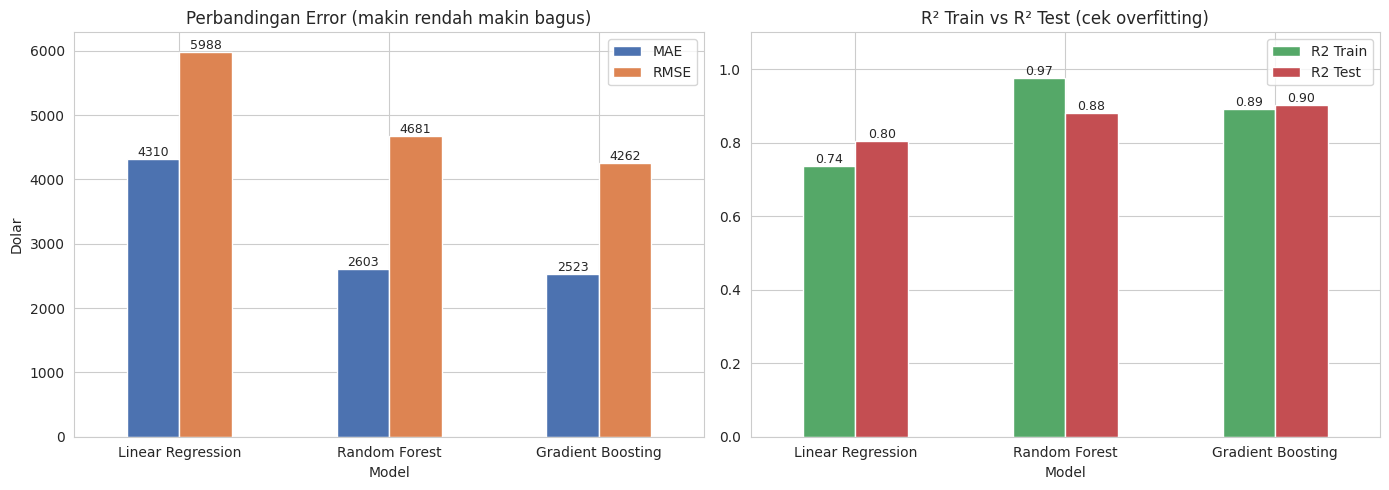

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_hasil[["MAE", "RMSE"]].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"], rot=0)
axes[0].set_title("Perbandingan Error (makin rendah makin bagus)")
axes[0].set_ylabel("Dolar")
for c in axes[0].containers:
    axes[0].bar_label(c, fmt="%.0f", fontsize=9)

df_hasil[["R2 Train", "R2 Test"]].plot(kind="bar", ax=axes[1], color=["#55A868", "#C44E52"], rot=0)
axes[1].set_title("R² Train vs R² Test (cek overfitting)")
axes[1].set_ylim(0, 1.1)
for c in axes[1].containers:
    axes[1].bar_label(c, fmt="%.2f", fontsize=9)

plt.tight_layout()
plt.show()

### Analisis Perbandingan

Dari tabel dan grafik di atas, urutan performanya dari yang terbaik adalah **Gradient Boosting > Random Forest > Linear Regression**.

Di grafik kiri kelihatan kalau kedua model berbasis pohon punya error yang jauh lebih kecil dibanding Linear Regression. MAE turun dari 4310 jadi sekitar 2500an. Tapi RMSE di ketiga model masih jauh di atas MAE-nya, artinya masih ada beberapa data yang tebakannya meleset lumayan jauh walaupun modelnya sudah bagus.

Di grafik kanan kelihatan bedanya soal overfitting. Random Forest punya selisih train dan test paling JAUH (0,97 vs 0,88), sedangkan Gradient Boosting batangnya hampir sejajar (0,89 vs 0,90). Jadi walaupun R² train Random Forest paling tinggi, yang beneran paling bisa diandalkan buat data baru tetap Gradient Boosting.

## 7. Visualisasi Hasil Prediksi pada Data Test

Grafik ini membandingkan nilai `charges` asli (sumbu X) dengan hasil tebakan model (sumbu Y) untuk setiap data test. Garis putus-putus hitam adalah garis **prediksi sempurna**, jadi makin dekat titik ke garis itu, makin tepat tebakannya. Titik di atas garis berarti model menebak KEMAHALAN, sedangkan titik di bawah garis berarti model menebak KEMURAHAN.

Titik-titiknya juga diwarnai berdasarkan status merokok, biar kelihatan apakah model lebih sering meleset di kelompok tertentu.

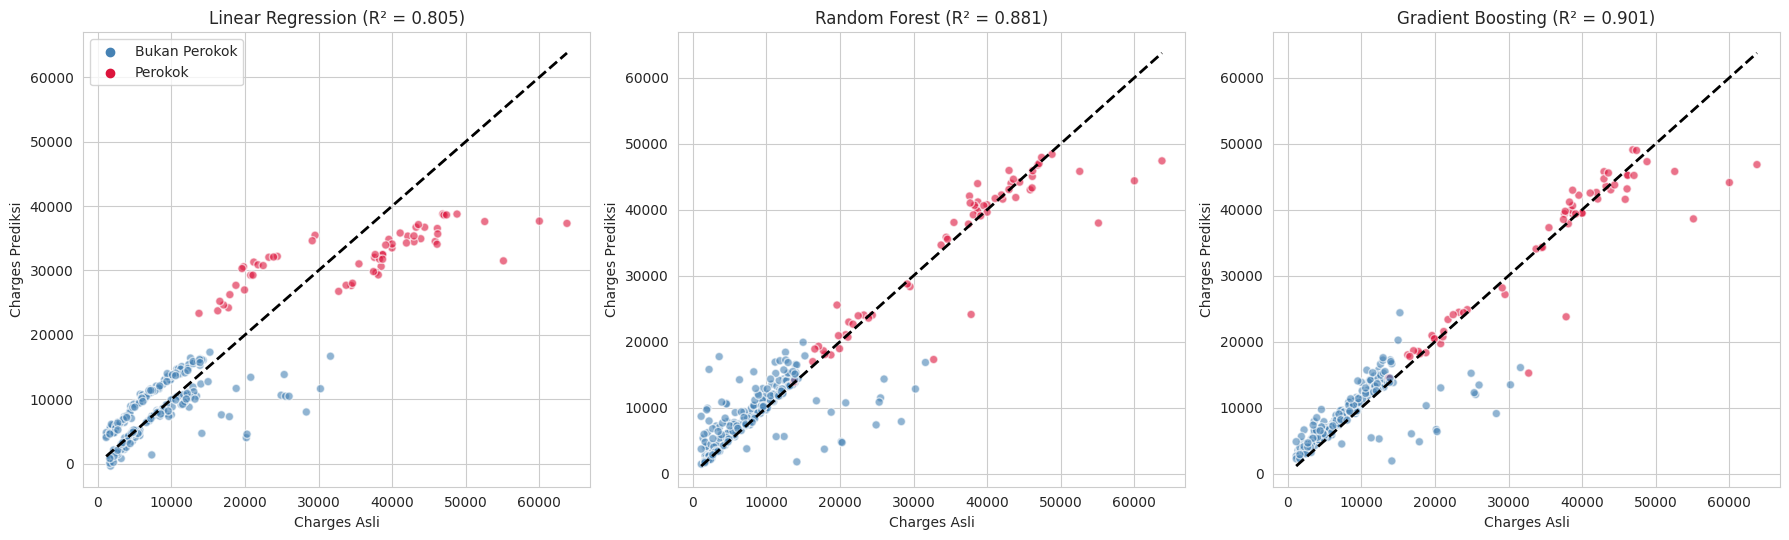

In [78]:
model_list = {"Linear Regression": lr, "Random Forest": rf, "Gradient Boosting": gb}
warna = X_test["smoker"].map({0: "steelblue", 1: "crimson"})

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (nama, model) in zip(axes, model_list.items()):
    pred = model.predict(X_test)
    ax.scatter(y_test, pred, c=warna, alpha=0.6, edgecolor="white")
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
    ax.set_title(f"{nama} (R² = {r2_score(y_test, pred):.3f})")
    ax.set_xlabel("Charges Asli")
    ax.set_ylabel("Charges Prediksi")

axes[0].scatter([], [], c="steelblue", label="Bukan Perokok")
axes[0].scatter([], [], c="crimson", label="Perokok")
axes[0].legend()
plt.tight_layout()
plt.show()

### Analisis Grafik Prediksi

Di grafik Linear Regression, titik merah (perokok) kelihatan TERBELAH jadi dua gerombolan. Gerombolan kiri, yaitu perokok dengan biaya sekitar 15 ribu sampai 30 ribu, posisinya di atas garis alias ditebak kemahalan. Sedangkan gerombolan kanan dengan biaya 35 ribu sampai 50 ribu posisinya di bawah garis alias ditebak kemurahan.

Ini karena di data aslinya, perokok yang obesitas biayanya melonjak jauh, sedangkan perokok yang tidak obesitas biayanya biasa saja. Linear Regression cuma bisa kasih satu nilai "tambahan biaya karena merokok" yang sama buat semua perokok, jadi hasilnya dirata-rata dan malah meleset ke dua arah sekaligus.

Di grafik Random Forest dan Gradient Boosting, titik merah sudah nempel rapi di sekitar garis. Artinya kedua model ini berhasil memisahkan perokok obesitas dan perokok non obesitas. Kesalahan yang tersisa kebanyakan datang dari titik biru yang jatuh jauh di bawah garis, yaitu peserta BUKAN perokok tapi biayanya mahal. Kemungkinan besar mereka punya faktor lain yang tidak tercatat di dataset, seperti riwayat penyakit, jadi model memang tidak punya petunjuk untuk menebaknya.

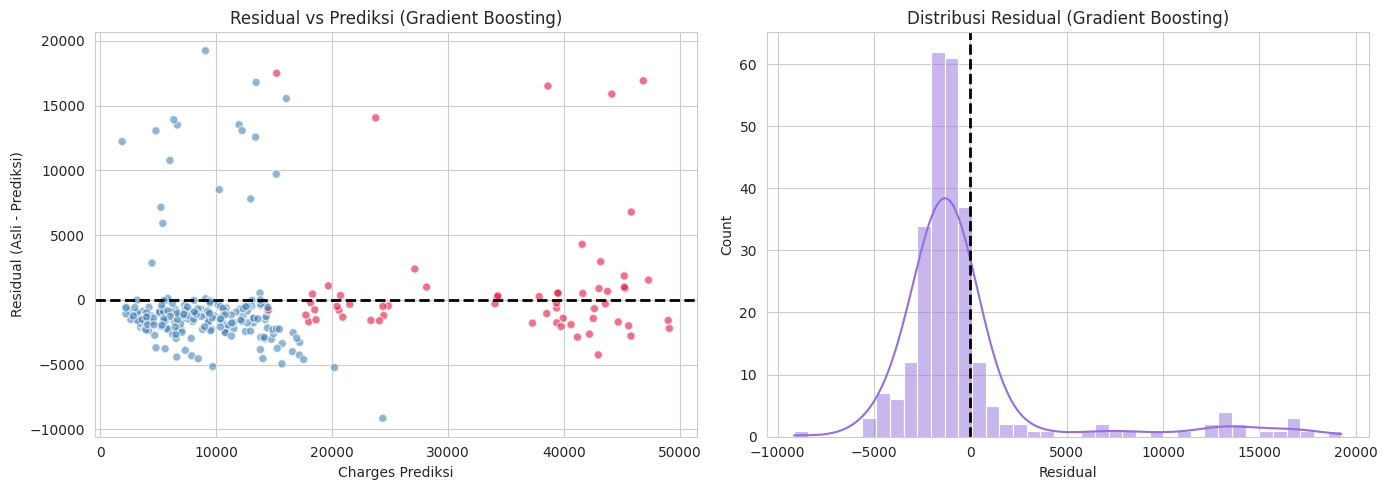

In [79]:
pred_gb = gb.predict(X_test)
residual = y_test - pred_gb

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pred_gb, residual, c=warna, alpha=0.6, edgecolor="white")
axes[0].axhline(0, color="black", linestyle="--", lw=2)
axes[0].set_title("Residual vs Prediksi (Gradient Boosting)")
axes[0].set_xlabel("Charges Prediksi")
axes[0].set_ylabel("Residual (Asli - Prediksi)")

sns.histplot(residual, bins=40, kde=True, ax=axes[1], color="mediumpurple")
axes[1].axvline(0, color="black", linestyle="--", lw=2)
axes[1].set_title("Distribusi Residual (Gradient Boosting)")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

### Analisis Residual Gradient Boosting

Dari grafik distribusi, sebagian besar residual menumpuk di rentang -5000 sampai 0. Artinya untuk kebanyakan peserta, model cuma meleset sedikit dan cenderung menebak sedikit kemahalan.

Tapi ada "ekor" panjang di sisi kanan sampai sekitar +19.000. Ini adalah beberapa peserta yang biaya aslinya jauh lebih mahal dari tebakan model. Di grafik kiri kelihatan kalau mereka kebanyakan titik biru (bukan perokok) di area prediksi rendah, plus beberapa perokok dengan biaya paling ekstrim.

Ekor inilah yang menjelaskan kenapa RMSE (4262) jauh lebih besar dari MAE (2523). RMSE menghukum error besar lebih berat, jadi segelintir kasus yang melesetnya PARAH ini langsung bikin nilainya naik, padahal mayoritas tebakan sebenarnya sudah cukup dekat.

# Kesimpulan Akhir

Notebook ini dikerjakan dalam tiga tahap besar, mulai dari mengenal data, membersihkan data, sampai akhirnya melatih model buat memprediksi biaya asuransi (`charges`).

**Posttest 1 (Eksplorasi Data)** nunjukkin kalau dataset ini hampir bersih, cuma ada 1 record duplikat. Temuan paling penting dari tahap ini adalah status MEROKOK jadi faktor terbesar yang bikin biaya asuransi melonjak, ditambah umur dan BMI.

**Posttest 2 (Prapemrosesan)** menyiapkan data biar bisa dibaca model. Outlier `bmi` ditangani pakai capping, dibuat dua fitur baru (`kategori_bmi` dan `skor_risiko`), semua attribute kategori diubah jadi angka, dan attribute numerik distandarisasi.

**Posttest 3 (Machine Learning)** memakai pendekatan Supervised Learning dengan tugas regresi, karena targetnya berupa angka kontinu. Ada tiga model yang dilatih dan dibandingkan:

| Model | MAE | RMSE | R² Train | R² Test |
|---|---|---|---|---|
| Linear Regression | 4310 | 5988 | 0,74 | 0,80 |
| Random Forest | 2603 | 4681 | 0,97 | 0,88 |
| Gradient Boosting | **2523** | **4262** | 0,89 | **0,90** |

Model terbaik adalah **Gradient Boosting**. Model ini punya R² test paling tinggi dan error paling kecil, dan R² train serta R² test-nya hampir sama, jadi dia benar-benar paham pola data dan bukan sekadar menghafal. Random Forest sebenarnya punya R² train paling tinggi (0,97), tapi justru itu tanda dia agak overfitting, karena performanya turun lumayan jauh waktu diuji di data test. Yang dipakai buat menilai model tetap performa di data test, karena itulah gambaran kemampuan model menghadapi data baru.

Linear Regression jadi model paling lemah karena hubungan antar fitur di dataset ini TIDAK LURUS. Biaya perokok yang obesitas melonjak jauh lebih tinggi dibanding perokok biasa, dan efek gabungan kayak gini nggak bisa ditangkap model garis lurus. Model berbasis pohon keputusan bisa menangkapnya karena aturannya bercabang.

Dari analisis residual, kesalahan yang tersisa paling banyak datang dari peserta bukan perokok yang biayanya mahal. Kemungkinan mereka punya faktor lain di luar dataset, seperti riwayat penyakit. Jadi kalau mau hasilnya lebih bagus lagi ke depannya, cara paling masuk akal adalah menambah data seperti riwayat kesehatan peserta, karena model cuma bisa belajar dari informasi yang dikasih ke dia.